# Plot Two LTF FFT Files\n
This notebook loads `ltf_fft1` and `ltf_fft2` from `.csv` or `.npy` and plots magnitude/phase.

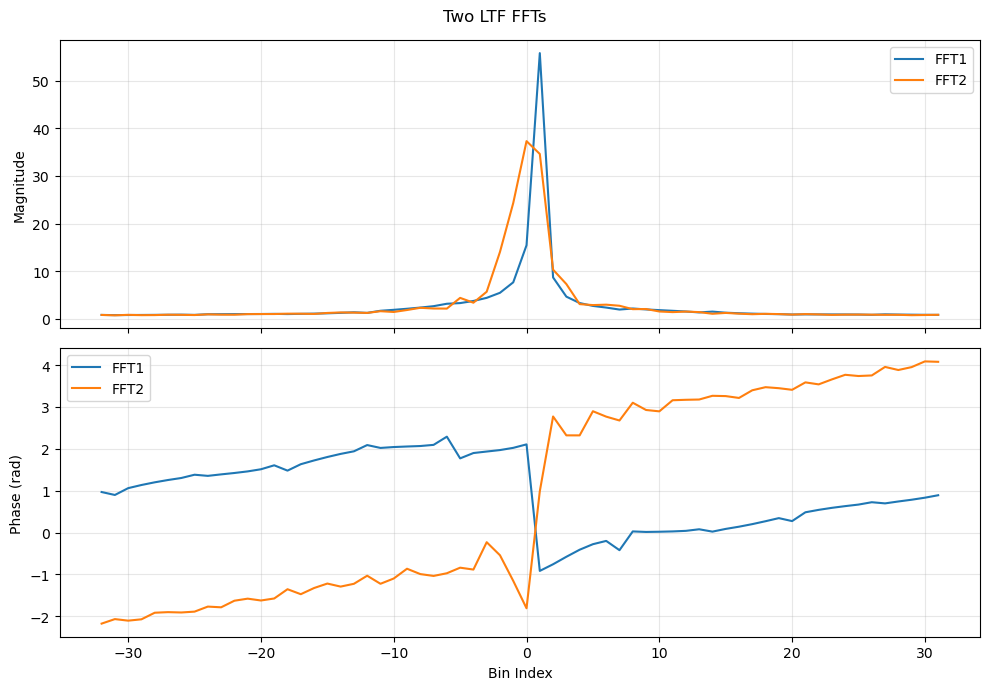

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ===== set your files =====
fft1_path = "ltf_fft1.csv"   # or "ltf_fft1.npy"
fft2_path = "ltf_fft2.csv"   # or "ltf_fft2.npy"
use_db = False
centered_bins = True         # True for -N/2..N/2-1 x-axis

def load_fft(path):
    ext = os.path.splitext(path)[1].lower()
    if ext == ".npy":
        x = np.load(path).astype(complex)
        bins = np.arange(len(x), dtype=int)
        return x, bins

    if ext == ".csv":
        data = np.loadtxt(path, delimiter=",", skiprows=1)
        if data.ndim != 2:
            raise ValueError(f"Unexpected CSV shape for {path}: {data.shape}")
        if data.shape[1] >= 3:
            # bin,real,imag,mag
            bins = data[:, 0]
            re = data[:, 1]
            im = data[:, 2]
        elif data.shape[1] >= 2:
            # real,imag
            bins = np.arange(len(data), dtype=int)
            re = data[:, 0]
            im = data[:, 1]
        else:
            raise ValueError(f"CSV must have at least 2 columns for {path}")
        return re + 1j * im, bins

    raise ValueError(f"Unsupported file type: {path}")

# load
x1, b1 = load_fft(fft1_path)
x2, b2 = load_fft(fft2_path)

# align lengths
n = min(len(x1), len(x2))
x1 = x1[:n]
x2 = x2[:n]
b1 = b1[:n]
b2 = b2[:n]

# x-axis bins
bins = b1 if len(b1) == n else np.arange(n)
if centered_bins:
    bins = np.arange(-n // 2, n // 2, dtype=int)

# magnitude + phase
mag1 = np.abs(x1)
mag2 = np.abs(x2)
if use_db:
    eps = 1e-12
    mag1 = 20 * np.log10(mag1 + eps)
    mag2 = 20 * np.log10(mag2 + eps)
    mag_ylabel = "Magnitude (dB)"
else:
    mag_ylabel = "Magnitude"

ph1 = np.unwrap(np.angle(x1))
ph2 = np.unwrap(np.angle(x2))

# plot
fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
fig.suptitle("Two LTF FFTs")

ax[0].plot(bins, mag1, label="FFT1")
ax[0].plot(bins, mag2, label="FFT2")
ax[0].set_ylabel(mag_ylabel)
ax[0].grid(True, alpha=0.3)
ax[0].legend()

ax[1].plot(bins, ph1, label="FFT1")
ax[1].plot(bins, ph2, label="FFT2")
ax[1].set_xlabel("Bin Index")
ax[1].set_ylabel("Phase (rad)")
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()


In [2]:
a = ((0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, (1.4719601443879746+1.4719601443879746j), 0.0, 0.0, 0.0, (-1.4719601443879746-1.4719601443879746j), 0.0, 0.0, 0.0, (1.4719601443879746+1.4719601443879746j), 0.0, 0.0, 0.0, (-1.4719601443879746-1.4719601443879746j), 0.0, 0.0, 0.0, (-1.4719601443879746-1.4719601443879746j), 0.0, 0.0, 0.0, (1.4719601443879746+1.4719601443879746j), 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, (-1.4719601443879746-1.4719601443879746j), 0.0, 0.0, 0.0, (-1.4719601443879746-1.4719601443879746j), 0.0, 0.0, 0.0, (1.4719601443879746+1.4719601443879746j), 0.0, 0.0, 0.0, (1.4719601443879746+1.4719601443879746j), 0.0, 0.0, 0.0, (1.4719601443879746+1.4719601443879746j), 0.0, 0.0, 0.0, (1.4719601443879746+1.4719601443879746j), 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0), (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, (1.4719601443879746+1.4719601443879746j), 0.0, 0.0, 0.0, (-1.4719601443879746-1.4719601443879746j), 0.0, 0.0, 0.0, (1.4719601443879746+1.4719601443879746j), 0.0, 0.0, 0.0, (-1.4719601443879746-1.4719601443879746j), 0.0, 0.0, 0.0, (-1.4719601443879746-1.4719601443879746j), 0.0, 0.0, 0.0, (1.4719601443879746+1.4719601443879746j), 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, (-1.4719601443879746-1.4719601443879746j), 0.0, 0.0, 0.0, (-1.4719601443879746-1.4719601443879746j), 0.0, 0.0, 0.0, (1.4719601443879746+1.4719601443879746j), 0.0, 0.0, 0.0, (1.4719601443879746+1.4719601443879746j), 0.0, 0.0, 0.0, (1.4719601443879746+1.4719601443879746j), 0.0, 0.0, 0.0, (1.4719601443879746+1.4719601443879746j), 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0), (0, 0j, 0, 0j, 0, 0j, -1, 1j, -1, 1j, -1, 1j, -1, -1j, 1, 1j, 1, -1j, -1, 1j, 1, 1j, 1, 1j, 1, 1j, -1, (-0-1j), 1, -1j, -1, 1j, 0, -1j, 1, (-0-1j), 1, -1j, 1, 1j, -1, -1j, 1, (-0-1j), -1, 1j, 1, 1j, 1, 1j, 1, 1j, -1, -1j, 1, 1j, 1, -1j, -1, 0j, 0, 0j, 0, 0j), (0, 0, 0, 0, 0, 0, 1, 1, -1, -1, 1, 1, -1, 1, -1, 1, 1, 1, 1, 1, 1, -1, -1, 1, 1, -1, 1, -1, 1, 1, 1, 1, 0, 1, -1, -1, 1, 1, -1, 1, -1, 1, -1, -1, -1, -1, -1, 1, 1, -1, -1, 1, -1, 1, -1, 1, 1, 1, 1, 0, 0, 0, 0, 0))

In [5]:
a[3]

(0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 -1,
 -1,
 1,
 1,
 -1,
 1,
 -1,
 1,
 1,
 1,
 1,
 1,
 1,
 -1,
 -1,
 1,
 1,
 -1,
 1,
 -1,
 1,
 1,
 1,
 1,
 0,
 1,
 -1,
 -1,
 1,
 1,
 -1,
 1,
 -1,
 1,
 -1,
 -1,
 -1,
 -1,
 -1,
 1,
 1,
 -1,
 -1,
 1,
 -1,
 1,
 -1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0)

In [4]:
import numpy as np

def load_symbols(path):
    symbols = []
    current = []

    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            if line == "xx":
                if current:
                    symbols.append(np.array(current, dtype=np.complex128))
                    current = []
                continue

            line = line.strip("()")
            re, im = line.split(",")
            current.append(complex(float(re), float(im)))

    if current:
        symbols.append(np.array(current, dtype=np.complex128))

    return symbols

symbols = load_symbols("zigbee_test.txt")

sym1 = symbols[0]
sym2 = symbols[1]

print("num symbols:", len(symbols))
print("len sym1:", len(sym1))
print("len sym2:", len(sym2))

print("symbol 1:")
print(sym1)

print("symbol 2:")
print(sym2)


num symbols: 10679
len sym1: 64
len sym2: 64
symbol 1:
[ 6.12496e-04-1.02411e-04j  4.91245e-04-1.58328e-05j
 -9.61354e-04-1.64425e-03j  1.44809e-03-1.67558e-03j
  3.54127e-04+2.46057e-03j  1.69149e-03-1.05059e-03j
  5.83727e-04+2.35967e-04j -2.55292e-03+1.90232e-04j
 -7.76697e-04-2.08960e-03j -1.62486e-03+2.46867e-05j
  9.17451e-04-9.75587e-04j -1.12991e-03-1.35568e-04j
  5.60856e-04-1.25272e-03j  1.63608e-03+3.60620e-03j
  8.85427e-04-5.45224e-04j  2.72040e-04+7.44767e-04j
 -1.88072e-04+1.46192e-03j -3.18784e-04+1.89344e-04j
 -1.59630e-04-6.60835e-04j -1.11660e-03+2.25079e-04j
 -7.84555e-04+1.01236e-03j  1.28504e-05+1.07616e-03j
 -1.39876e-04-7.71194e-04j  3.32443e-03+5.26579e-04j
  3.47660e-03-6.67603e-04j  1.22992e-03+1.19982e-03j
  4.67190e-04+1.18661e-03j -4.18114e-03+6.29648e-04j
 -2.22757e-03-9.99576e-04j  6.30781e-04+1.76085e-03j
  5.92823e-04+4.64834e-03j -8.93639e-04-1.78830e-04j
  1.69396e-03+1.62340e-02j  4.03446e-03-4.96942e-04j
  2.00635e-03+1.58524e-03j  1.81605e-03-1.55

In [7]:
sym2[32]

(0.0159544+0.00926134j)

In [8]:

sym1[32]

(0.00169396+0.016234j)

In [13]:
import numpy as np

def load_symbols(path):
    symbols = []
    current = []

    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            if line == "xx":
                if current:
                    symbols.append(np.array(current, dtype=np.complex128))
                    current = []
                continue

            line = line.strip("()")
            re, im = line.split(",")
            current.append(complex(float(re), float(im)))

    if current:
        symbols.append(np.array(current, dtype=np.complex128))

    return symbols

symbols = load_symbols("zigbee_test.txt")

sym1 = symbols[0]
sym2 = symbols[1]

print("num symbols:", len(symbols))
print("len sym1:", len(sym1))
print("len sym2:", len(sym2))

# DC bin after fftshift for N=64
dc_bin = 32

# Received values Y
Y1 = sym1[dc_bin]
Y2 = sym2[dc_bin]

# Known reference values X
X1 = -7.863961030678916941 + 1j * 13.27817459305200920
X2 = -8.746803743153531485 - 1j * 36.28893936688451305

# Per-LTF channel estimates
H1 = Y1 / X1
H2 = Y2 / X2

# Average channel estimate
H_avg = (H1 + H2) / 2

print("Y1 =", Y1)
print("Y2 =", Y2)
print("X1 =", X1)
print("X2 =", X2)
print("H1 =", H1)
print("H2 =", H2)
print("H_avg =", H_avg)


num symbols: 5847
len sym1: 64
len sym2: 64
Y1 = (0.00469869-0.0077202j)
Y2 = (0.00361641+0.00697037j)
X1 = (-7.863961030678917+13.27817459305201j)
X2 = (-8.746803743153531-36.28893936688451j)
H1 = (-0.0005855948870898267-7.04875715444782e-06j)
H2 = (-0.0002042347138623733+5.042883788377344e-05j)
H_avg = (-0.00039491480047609996+2.169004036466281e-05j)
